## 환경 설정 

In [21]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold

from transformers import AutoProcessor, AutoModelForVision2Seq, Kosmos2ForConditionalGeneration

from trl import SFTTrainer, SFTConfig

from datasets import load_dataset, Dataset, load_from_disk
from peft import LoraConfig, get_peft_model, PeftModel

In [7]:
# # !! Important HOTFIX !!
# import transformers.models.kosmos2.modeling_kosmos2 as kosmos2_module

# original_forward_embedding = kosmos2_module.Kosmos2TextTransformer.forward_embedding

# def patched_forward_embedding(self, input_ids, inputs_embeds, image_embeds, img_input_mask, past_key_values_length, position_ids):
#     if inputs_embeds is not None:
#         inputs_embeds = inputs_embeds.clone()
#     return original_forward_embedding(
#         self, input_ids, inputs_embeds, image_embeds,
#         img_input_mask, past_key_values_length, position_ids
#     )

# kosmos2_module.Kosmos2TextTransformer.forward_embedding = patched_forward_embedding


In [22]:
# 환경 설정
warnings.filterwarnings("ignore")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

✅ Using device: cuda


## 시드고정

In [9]:
# 시드 고정
def seed_everything(seed=47):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

## 모델 선언

In [ ]:
model = Kosmos2ForConditionalGeneration.from_pretrained("microsoft/kosmos-2-patch14-224", device_map='auto', torch_dtype=torch.bfloat16, _attn_implementation="sdpa",)
processor = AutoProcessor.from_pretrained("microsoft/kosmos-2-patch14-224", add_eos_token=True)

# 모델 정보
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 정보:")
print(f"총 파라미터 수: {total_params:,}")

In [ ]:
print(model)

In [ ]:
processor.tokenizer.SPECIAL_TOKENS_ATTRIBUTES
processor.tokenizer.special_tokens_map_extended
processor.tokenizer.convert_tokens_to_ids(["<image>", "</image>"])

## 데이터 collator

In [ ]:
class DataCollator:
    def __init__(self, processor, model_dtype=torch.float32):
        self.processor = processor
        self.model_dtype = model_dtype

    def __call__(self, examples):
        '''
        Dataset에서 
        image는 PIL 이미지이길 기대
        choices는 List[str] 형태이길 기대
        description은 하나의 긴 str이길 기대
        answer은 A, B, C, D 중 하나일 것으로 기대        
        '''
        images = []
        texts = []
        instructions = [] 

        for example in examples:
            images.append(example['image'])
            instruction = f"Describe this image in detail."
            instructions.append(instruction)
            
            full_answer = f"Description: {example['description']}"
            texts.append('\n'.join([instruction, full_answer]))

        batch = self.processor(images=images, text=texts, padding=True, truncation=True, return_tensors="pt")
        batch['pixel_values'] = batch['pixel_values'].to(self.model_dtype)
        instruction_batch = self.processor(images=images, text=instructions, padding=True, truncation=True, return_tensors="pt", add_eos_token=False)
        
        # `labels`는 `input_ids`를 복사하여 시작합니다.
        labels = batch["input_ids"].clone()
        
        # 안전성 체크
        if labels is None or labels.numel() == 0:
            print(f"ERROR: DataCollator: labels is None or empty. Example inputs that led to this: {examples}")
            raise ValueError("DataCollator produced None or empty labels. Check your data or processor.")
        
        # 패딩 토큰 마스킹: 패딩된 부분은 Loss 계산에서 제외합니다.
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        # 각 샘플의 instruction_lengths에 따라 labels의 해당 부분을 -100으로 설정합니다.
        for i in range(len(examples)):
            # instruction 배치에서 실제 토큰 길이 계산 (패딩 제외)
            instruction_tokens = instruction_batch["input_ids"][i]
            # 패딩이 아닌 토큰들의 개수 계산
            non_pad_mask = instruction_tokens != self.processor.tokenizer.pad_token_id
            actual_instruction_length = non_pad_mask.sum().item()
            # instruction 부분을 -100으로 마스킹
            mask_len = min(actual_instruction_length, labels.shape[1])
            labels[i, :mask_len] = -100
            
            # # DEBUG:: -100으로 마스킹되지 않은 부분만 디코딩해서 출력
            # valid_tokens = labels[i][labels[i] != -100]  # -100이 아닌 토큰들만 추출
            # if len(valid_tokens) > 0:
            #     decoded_text = self.processor.tokenizer.decode(valid_tokens, skip_special_tokens=False)
            #     print(f"Sample {i} - Valid labels decoded: \n{decoded_text}")
            # else:
            #     print(f"Sample {i} - No valid tokens to decode")

        batch["labels"] = labels
        
        return batch



data_collator = DataCollator(processor, model_dtype=torch.bfloat16)

## 데이터셋

In [ ]:
# DACON 오피셜 데이터셋
# 경로때문에 이 ipynb 파일에서만 작동함.
class DACONDataset(torch.utils.data.Dataset):
    """DACON official dataset."""

    def __init__(self, dataset):
        self.dataset = dataset.remove_columns(["ID"])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # get image + text
        sample = self.dataset[idx]
        
        return {"image": Image.open(f"../../eg/{sample['img_path']}").convert('RGB'), 
                "question": sample['Question'], 
                "choices": [sample[c] for c in ['A', 'B', 'C', 'D']], 
                "description": sample['description'],
                "answer": sample['answer']  }
        
        
dacon_ds = load_dataset("json", data_files="../../eg/train_aug.jsonl", split='train')
dacon_ds = DACONDataset(dacon_ds)
dacon_ds[1]

In [ ]:
# batch 테스트
image = Image.open(os.path.join("../../eg/", example['img_path']))
batch = processor(images=image, text=example['Question']+"\nThe final answer is: B", padding=True, truncation=True, return_tensors="pt")
# print("pixel_values: ", batch["pixel_values"])
# print("input_ids: ", batch["input_ids"])
# print("attention_mask: ", batch["attention_mask"])
# print("image_embeds_position_mask: ", batch["image_embeds_position_mask"])
print(processor.batch_decode(batch['input_ids']))

instruct = processor(images=image, text=example['Question'], add_eos_token=False, return_tensors="pt")
# print("pixel_values: ", batch["pixel_values"])
# print("input_ids: ", batch["input_ids"])
# print("attention_mask: ", batch["attention_mask"])
# print("image_embeds_position_mask: ", batch["image_embeds_position_mask"])
print(processor.batch_decode(instruct['input_ids']))

print(len(batch['input_ids'][0]), len(instruct['input_ids'][0]))

batch['input_ids'][0][: len(instruct['input_ids'][0]) ] = 1
print(processor.batch_decode(batch['input_ids']))

In [ ]:
from datasets import load_dataset

# ds = load_dataset("UCSC-VLAA/Recap-COCO-30K", split="train")
# ds = load_dataset("UCSC-VLAA/Recap-DataComp-1B", "default")

## SFT Trainer

In [ ]:
training_args = SFTConfig(
    report_to='none',
    run_name = 'run-0717',
    output_dir="foobar",
    num_train_epochs=1,
    per_device_train_batch_size=3,
    per_device_eval_batch_size=3,
    gradient_accumulation_steps=4,
    learning_rate=1e-5,
    weight_decay=0.01,
    logging_steps=25,
    eval_strategy='epoch',
    save_strategy="epoch",
    optim="adamw_torch_fused",
    bf16=True,
    remove_unused_columns=False,
    gradient_checkpointing=True,
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    eval_do_concat_batches=False,
    label_names=["labels"],
)

In [ ]:
print(model)

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules= 'all-linear',
    exclude_modules=["vision_model"],
    lora_dropout=0.05,
    bias="none",
)

In [ ]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dacon_ds,
    eval_dataset=dacon_ds,
    # peft_config=lora_config,
    data_collator=data_collator,
)
trainer.args.predict_with_generate = True
# trainer.train()

In [ ]:
output = trainer.predict(dacon_ds)

In [ ]:
# print(type(output.predictions), len(output.predictions))  # 원본 pred는 datalength / batch 의 길이를 가진 tuple
# print(type(output.label_ids), len(output.label_ids))

# print(output.predictions[0])    # output.predictions[i] 는 i번째 batch. batch_size 길이의 tuple
# print(output.predictions[0][0].shape)   # output.predictions[i][j] 는 batch 안에서 j번째. 0, 1은 np.ndarray 타입. 2는 transformers.modeling_outputs.BaseModelOutputWithPooling 타입
pred_texts = []
for batch_preds in output.predictions:
    logits = batch_preds[0]
    token_ids = np.argmax(logits, axis=-1)
    decoded_preds = processor.tokenizer.batch_decode(token_ids, skip_special_tokens=True)
    pred_texts.extend([pred for pred in decoded_preds])

label_texts = []
for batch_label in output.label_ids:
    sample = batch_label    # batch size만큼의 길이를 가진 encoded list
    encoded_labels = np.where(sample == -100, processor.tokenizer.pad_token_id, sample)
    decoded_labels = processor.tokenizer.batch_decode(encoded_labels, skip_special_tokens=True) # batch size의 decoded text list가 됨
    label_texts.extend([label for label in decoded_labels])

from evaluate import load
meteor = load("meteor")
batch_res = meteor.compute(predictions=pred_texts, references=label_texts)
batch_res

## 더미입력으로 확인

In [ ]:
# 더미입력으로 확인
try:
    from PIL import Image
    import numpy as np
    import requests
    
    # PIL 이미지로 더미 이미지 생성 (RGB, 224x224)
    # dummy_image_array = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
    # dummy_image = Image.fromarray(dummy_image_array, mode='RGB')
    url = "https://raw.githubusercontent.com/salesforce/LAVIS/main/docs/_static/Confusing-Pictures.jpg"
    dummy_image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
    dummy_text = "Describe this image."
    
    print("더미 이미지 생성 완료")
    print(f"이미지 크기: {dummy_image.size}, 모드: {dummy_image.mode}")
    
    # 입력 전처리
    inputs = processor(
        images=dummy_image, 
        text=dummy_text, 
        return_tensors="pt"
    )
    
    print("입력 전처리 완료")
    print(f"입력 텐서 키: {list(inputs.keys())}")
    print(f"이미지 텐서 shape: {inputs['pixel_values'].shape}")
    print(f"텍스트 토큰 shape: {inputs['input_ids'].shape}")
    
    # T5 모델을 위한 decoder_input_ids 생성
    # T5는 decoder 시작 시 pad_token_id를 사용
    batch_size = inputs['input_ids'].shape[0]
    decoder_input_ids = torch.full(
        (batch_size, 1), 
        processor.tokenizer.pad_token_id, 
        dtype=torch.long
    )
    inputs['decoder_input_ids'] = decoder_input_ids
    
    print(f"decoder_input_ids 추가: {decoder_input_ids.shape}")
    
    # Forward pass 테스트 (training mode)
    model.train()  # training mode로 설정
    with torch.no_grad():
        outputs = model(**inputs)
    
    print("✓ Forward pass 성공")
    print(f"출력 logits shape: {outputs.logits.shape}")
    print(f"출력 logits 범위: [{outputs.logits.min().item():.4f}, {outputs.logits.max().item():.4f}]")
    
    # Generation 테스트도 수행
    print("\nGeneration 테스트...")
    model.eval()  # evaluation mode로 설정
    with torch.no_grad():
        # decoder_input_ids 제거 (generate에서는 자동 생성)
        gen_inputs = {k: v for k, v in inputs.items() if k != 'decoder_input_ids'}
        generated_ids = model.generate(
            **gen_inputs,
            max_new_tokens=30,
            do_sample=True,
            num_beams=3,
            repetition_penalty=1.5,
        )
    
    # 생성된 텍스트 디코딩
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print(f"✓ Generation 성공")
    print(f"생성된 텍스트 (샘플): '{generated_text}...'")
      
    
except Exception as e:
    print(f"✗ 테스트 실패: {str(e)}")
    # 에러 발생 시 더 자세한 디버깅 정보 제공
    import traceback
    print("상세 에러 정보:")
    traceback.print_exc()


print("\n모델 개조 및 테스트 완료!")

In [ ]:
# A-OKVQA 데이터셋
train_ds = load_dataset("HuggingFaceM4/A-OKVQA", split="train[:50]")
val_ds = load_dataset("HuggingFaceM4/A-OKVQA", split="validation[:10]")

a = len(train_ds)
# 데이터 유효성 확인
train_ds = train_ds.filter(lambda example: len(example['choices']) == 4)
train_ds = train_ds.filter(lambda example: example['correct_choice_idx'] in [0,1,2,3])
print(f"필터링된 샘플 갯수: {len(train_ds) - a}")

In [ ]:
# A-OKVQA 데이터셋
class AokvqaDataset(torch.utils.data.Dataset):
    """A-OKVQA dataset."""

    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # get image + text
        sample = self.dataset[idx]
        answer_idx = sample['correct_choice_idx']
        answer = sample['choices'][answer_idx]
        image = sample['image'].convert('RGB')
        prompt = f"""
        Based on the image, choose the correct option to the following question.

        Question: {sample['question']}

        Options:
        A. {sample['choices'][0]}
        B. {sample['choices'][1]}
        C. {sample['choices'][2]}
        D. {sample['choices'][3]}

        Answer:
        """
        encoding = self.processor(image, prompt, padding="max_length", max_length=512, truncation=True, return_tensors="pt")
        
        # remove batch dimension
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        label_encoding = self.processor.tokenizer(
            f'{chr(65+answer_idx)}. {answer}',
            max_length=128, # 라벨의 최대 길이 (충분히 크게)
            padding="max_length", # 여기서는 max_length 패딩이 적절
            truncation=True,
            return_tensors="pt"
        )
        encoding["labels"] = label_encoding.input_ids.squeeze(0)
        encoding["labels"][encoding["labels"] == self.processor.tokenizer.pad_token_id] = -100
        return encoding
    

def collate_fn(batch):
    # 'pixel_values', 'qformer_input_ids', 'qformer_attention_mask', 'input_ids', 'attention_mask', 'labels'
    # 이 모든 키들이 배치로 쌓여야 합니다.
    processed_batch = {}
    for key in batch[0].keys():
        processed_batch[key] = torch.stack([sample[key] for sample in batch])
        
    return processed_batch
    
    
train_ds = AokvqaDataset(dataset=train_ds, processor=processor)
val_ds = AokvqaDataset(dataset=val_ds, processor=processor)

## Inference sample

In [23]:
from transformers import AutoProcessor, AutoModelForVision2Seq


# model = AutoModelForVision2Seq.from_pretrained("microsoft/kosmos-2-patch14-224")
# processor = AutoProcessor.from_pretrained("microsoft/kosmos-2-patch14-224")
# # --------------------- [Optional] 모델 로드 for continual training -----------------------
final_save_directory = os.path.join("/mnt/workspace/Model/kosmos2/2nd_phase/final_best_model")
model = Kosmos2ForConditionalGeneration.from_pretrained("microsoft/kosmos-2-patch14-224", torch_dtype=torch.bfloat16, device_map="auto" )   # 베이스모델 로드
model = PeftModel.from_pretrained(model, final_save_directory, torch_dtype=torch.bfloat16, device_map="auto", is_trainable=True )       # LoRA weight 적용된 모델 로드
processor = AutoProcessor.from_pretrained(final_save_directory, add_eos_token=True)

Describe this image in detail. Description: A woman is standing in a field, holding an ice cream cone in her hand. She is wearing a white shirt and a black skirt, and her hair is tied back. The field is surrounded by trees, and there is a clear blue sky in the background. 



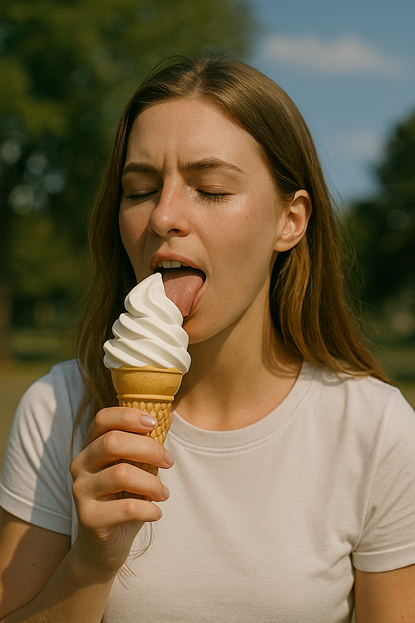

In [24]:
from IPython.display import clear_output

# ds = load_dataset("json", data_files="../../eg/train_aug.jsonl", split='train')
ds = pd.read_csv('../../eg/test.csv')[0:10]

for i ,row in ds.iterrows():
    path = os.path.join('/mnt/workspace/eg', row['img_path'])
    image = Image.open(path)
    
    inputs = processor(text="Describe this image in detail.", images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values=inputs["pixel_values"].to(device),
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            image_embeds=None,
            image_embeds_position_mask=inputs["image_embeds_position_mask"],
            use_cache=True,
            max_new_tokens=2048,
            do_sample=False,
            num_beams=3
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    processed_text, entities = processor.post_process_generation(generated_text)
    print(processed_text,'\n')
    image.show()
    # print(row['description'])
    input(f"[{i}/{len(ds)}] 다음을 보려면 Enter를 누르세요...")
    clear_output(wait=True)

In [ ]:
import requests
from PIL import Image

model.eval()

url = "https://raw.githubusercontent.com/salesforce/LAVIS/main/docs/_static/Confusing-Pictures.jpg"
# url = "https://huggingface.co/microsoft/kosmos-2-patch14-224/resolve/main/snowman.png"
# url = "https://huggingface.co/microsoft/kosmos-2-patch14-224/resolve/main/two_dogs.jpg"
image = Image.open(requests.get(url, stream=True).raw)

# The original Kosmos-2 demo saves the image first then reload it. For some images, this will give slightly different image input and change the generation outputs.
# image.save("new_image.jpg")
# image = Image.open("new_image.jpg")
prompt = 'Describe this image in detail.'
inputs = processor(text=prompt, images=image, return_tensors="pt").to(device)

generated_ids = model.generate(
    pixel_values=inputs["pixel_values"].to(device),
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    image_embeds=None,
    image_embeds_position_mask=inputs["image_embeds_position_mask"],
    use_cache=True,
    max_new_tokens=128,
)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# Specify `cleanup_and_extract=False` in order to see the raw model generation.
processed_text = processor.post_process_generation(generated_text, cleanup_and_extract=False)

print(processed_text,'\n')
# `<grounding> An image of<phrase> a snowman</phrase><object><patch_index_0044><patch_index_0863></object> warming himself by<phrase> a fire</phrase><object><patch_index_0005><patch_index_0911></object>.`

# By default, the generated  text is cleanup and the entities are extracted.
processed_text, entities = processor.post_process_generation(generated_text)

print(processed_text,'\n')
# `An image of a snowman warming himself by a fire.`

print(entities,'\n')
# `[('a snowman', (12, 21), [(0.390625, 0.046875, 0.984375, 0.828125)]), ('a fire', (41, 47), [(0.171875, 0.015625, 0.484375, 0.890625)])]`


## Submission

In [ ]:
# 추론
test = pd.read_csv('../../eg/test.csv')[10:20]
results = []

# 정답 알파벳 추출 함수
def extract_answer_letter(text):
    match = re.search(r"\s*([A-Da-d])\s*", text)
    return match.group(1).upper() if match else "?"

model.to('cuda')
for _, row in tqdm(test.iterrows(), total=len(test)):
    image = Image.open('../../eg/'+row['img_path'])
    choices = '\n'.join([f"{c}. {row[c]}" for c in ['A', 'B', 'C', 'D']])
    
    prompt = f"Describe this image in detail."

    # 🔹 전처리
    inputs = processor(images=image, text=prompt, return_tensors="pt").to('cuda')

    # # 🔹 추론
    with torch.no_grad():
        generated_ids = model.generate(
            # **inputs,
            pixel_values=inputs["pixel_values"],
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            image_embeds=None,
            image_embeds_position_mask=inputs["image_embeds_position_mask"],
            use_cache=True,
            max_new_tokens=128,
        )
    # Trim the generated ids to remove the input ids
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # By default, the generated  text is cleanup and the entities are extracted.
    processed_text, entities = processor.post_process_generation(generated_text)
    image.show()
    tqdm.write(processed_text)

print('✅ Done.')

In [ ]:
submission = pd.read_csv('./sample_submission.csv')
submission['answer'] = results
submission.to_csv('./baseline_submit.csv', index=False)
print("Done.")

# 데이터셋 증강

In [ ]:
import torch
import torchvision.transforms as T
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer
from tqdm import tqdm
from datasets import load_dataset

In [ ]:
IMAGENET_MEAN = (0.5, 0.5, 0.5)
IMAGENET_STD = (0.5, 0.5, 0.5)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=10, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_data, input_size=384, max_num=10):
    image = Image.open(image_data).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

In [ ]:
import os
import json
from PIL import Image
from tqdm import tqdm
import torch
from transformers import AutoModel, AutoTokenizer
# load_dataset을 사용하기 위해 datasets 라이브러리 임포트
from datasets import load_dataset


model_path = 'LiAutoAD/Ristretto-3B'
model = AutoModel.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True).eval().cuda()
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True, use_fast=False)

generation_config = dict(min_new_tokens=20, max_new_tokens=128, repetition_penalty=1.2, length_penalty = 1.1, do_sample=False, num_beams=5)